In [2]:
# # core point : 반지름안에 있는 점들을 찾는 문제
# core point >= min_samples(최소기준)
# core->core->core : 자연스럽게 군집을 형성
# 밀도가 높은 곳은 계속 연결되어 있다->하나의 큰 덩어리인 클러스터
# 반지름안에 있는 점들을 찾는 문제는 주어진 중심점과 반지름을 기준으로, 
# 해당 반지름 안에 위치한 점들을 찾는 문제입니다. 
# 이 문제는 주로 2차원 평면에서 다루어지며, 중심점과 반지름이 주어졌을 때, 
# 해당 반지름 안에 있는 점들의 좌표를 반환하는 방식으로 해결됩니다.
# - 이 문제를 해결하기 위해서는 다음과 같은 단계를 거칠 수 있습니다:  

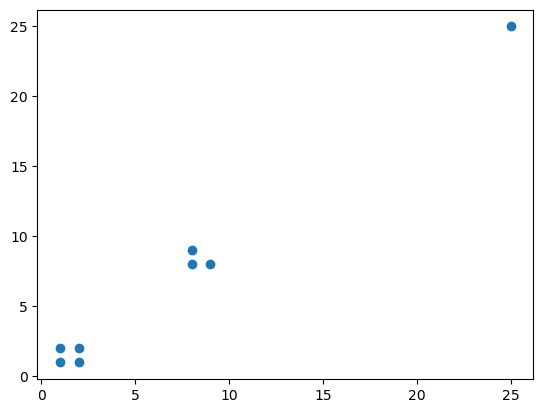

In [3]:
# 샘플데이터
import numpy as np
import matplotlib.pyplot as plt
X = np.array(
    [[1,1],[1,2],[2,1],[2,2],[8,8],[8,9],[9,8],[25,25]]
)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [4]:
import numpy as np
# 반지름 1.5안에 3개이상 있으면 core point
esp=1.5
min_samples=3
# 현재점 p0(1,1)
round(np.sqrt((2-1)**2 + (2-1)**2),1)
# 이웃 4
# p0(1,1) p1(1,2) p2(2,1) p3(2,2)
# 주변찾기 p1->p2->p3

1.4

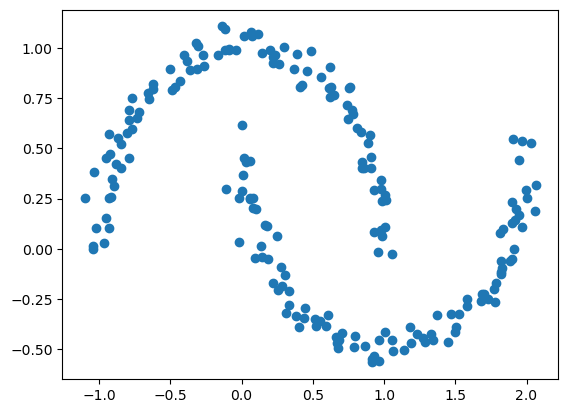

In [5]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons
np.random.seed(42)
X,y =  make_moons(
    n_samples=200,
    noise=0.05, random_state=42
)
plt.scatter(X[:,0], X[:,1])
plt.show()


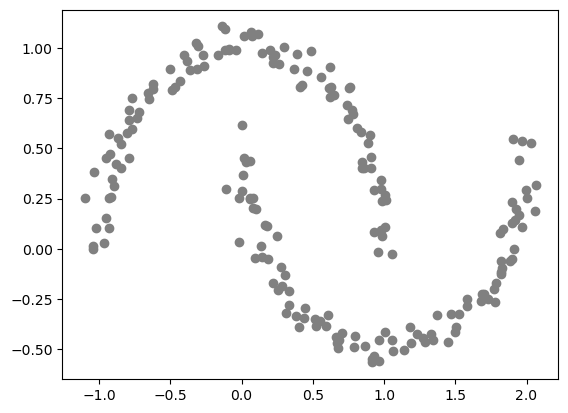

In [6]:
# step 1 초기화(모든점 미방문)
UNVISITED = -1
NOISE = -2
n = len(X)
labels = np.full(n, UNVISITED)

esp = 1.0
min_samples = 5
cluster_id = 0
plt.scatter(X[:,0], X[:,1],c='gray')
plt.show()

In [7]:
# step 2 : 반경내 이웃찾기
def region_query(X, point_idx, eps):
    '''
    X : 전체데이터셋
    point_idx : 기준점 Core point후보 인덱스
    eps : 이웃으로인정하기위한 최대거리 즉 반경(Epsilon)
    '''
    distance = np.linalg.norm(    
        X - X[point_idx],
        axis=1  # 열단위로 연산
    )
    return np.where(distance <= esp)[0]

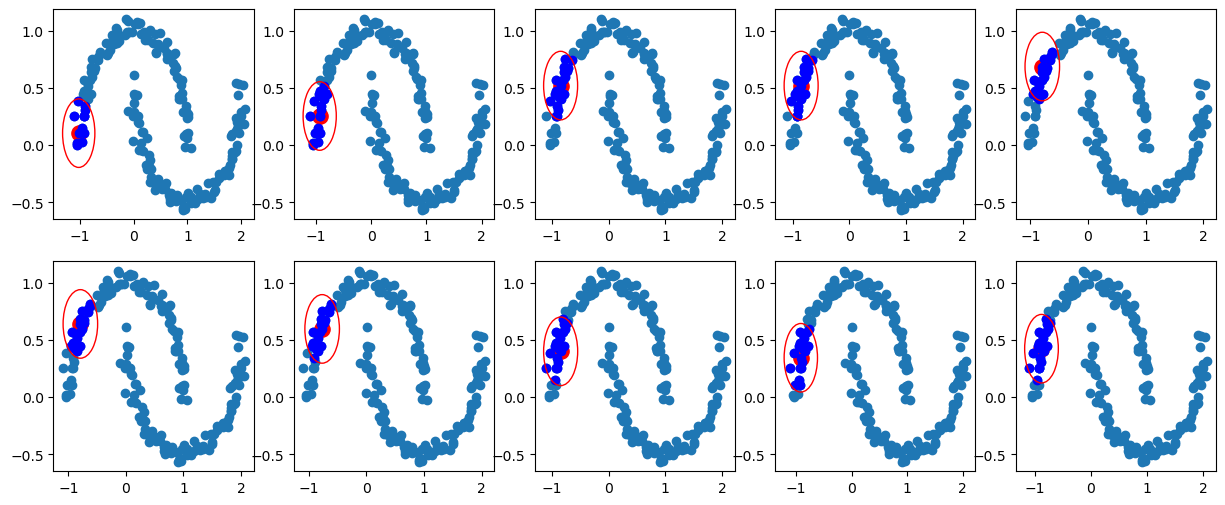

In [8]:
# step3 Core Pont 확인
neighbors = region_query(X, 0, esp)
esp = 0.3
fig, ax = plt.subplots(2,5,figsize=(15,6))
for i in range(10):
    point_index = neighbors[i]
    
    neighbors = region_query(X, point_index, esp)
    # 전체점
    ax[i//5, i%5].scatter(X[:,0], X[:,1])

    # 현재 점
    ax[i//5, i%5].scatter(
        X[point_index,0], X[point_index,1],
        c='red',s=120
    )
    # 이웃점
    ax[i//5, i%5].scatter(
        X[neighbors,0], X[neighbors,1],
        c='blue'
    )   

    # esp 원
    circle = plt.Circle(
        X[point_index], esp, color='red',fill=False
    )
    ax[i//5, i%5].add_patch(circle)
plt.show()

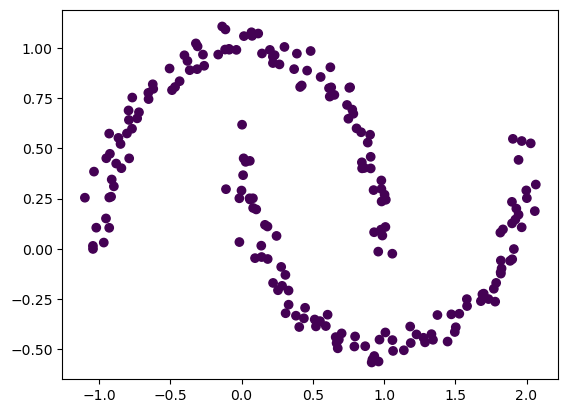

In [9]:
# 라이브러리 이용
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.5, min_samples=5)
sk_labels = model.fit_predict(X)
plt.scatter(
    X[:,0], X[:,1], c=sk_labels
)
plt.show()

In [10]:
# 계층적 군집화
# 처음에는 모든 점이 혼자 있음
# 가장 가까운 두 점 찾기
# 그 둘을 하나의 그룹으로 묶기
# 다시 가장 가까운 그룹 찾기
# 반복
# 결국 하나의 큰 그룹이 됨
# ex) 섬들이 점점 다리로 연결되는 과정

# 덴드로그램(dendrogram)

In [11]:
# 군집 간 거리
# Linkage Criterion
# Single Linkage(가장 가까운 점 위주)
# Complete Linkage(가장 먼 점 기준)
# Average Linkage(모든 점 거리 평균)

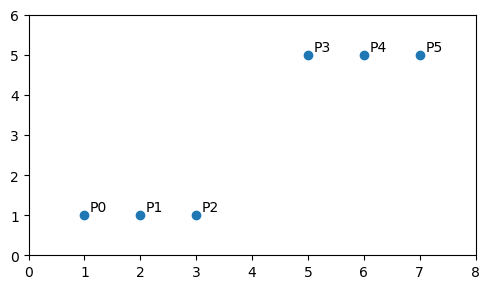

In [16]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,3))
# 사슬 모양
X = np.array([
    [1,1,],[2,1],[3,1],[5,5],[6,5],[7,5]
])

plt.scatter(X[:, 0], X[:, 1]) # 모든 row에 0, 1번째

for i, (x,y) in enumerate(X):
    plt.text(x+0.1, y+0.1, f'P{i}')

plt.xlim(0,8)
plt.ylim(0,6)
plt.tight_layout()

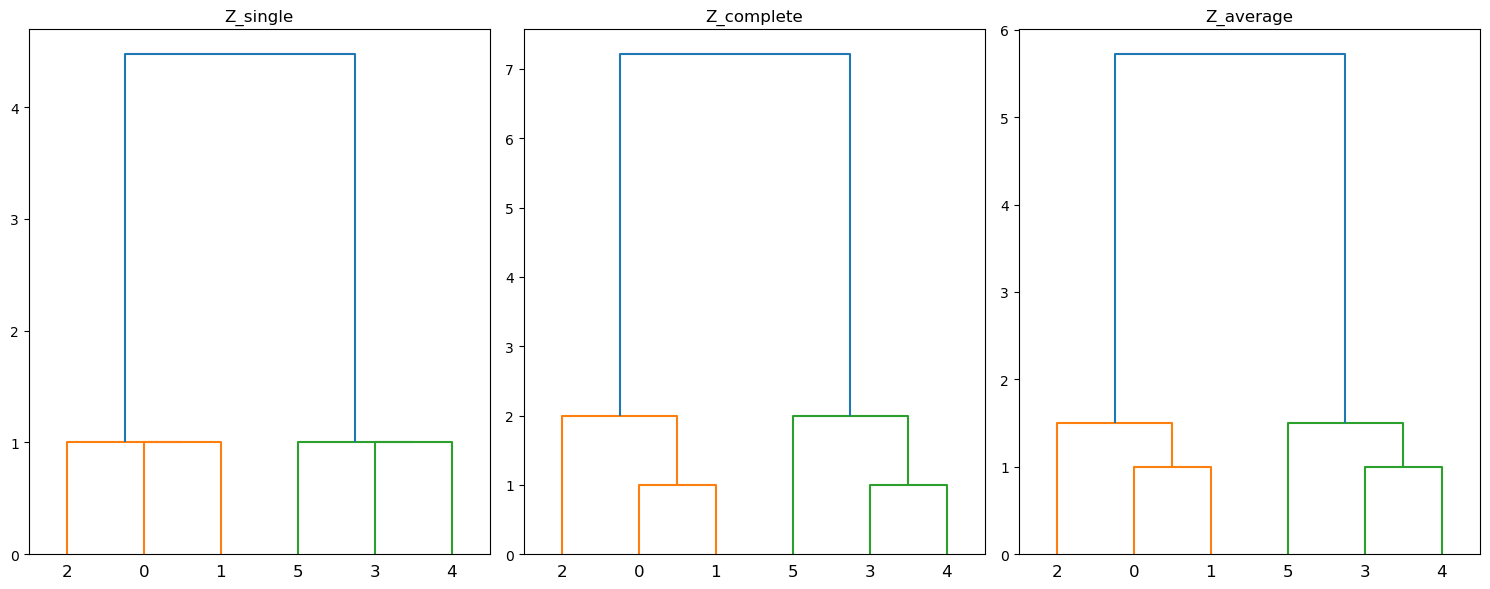

In [19]:
from scipy.cluster.hierarchy import linkage

Z_single = linkage(X, method= 'single')
Z_complete= linkage(X, method= 'complete')
Z_average = linkage(X, method= 'average')

from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(1, 3, figsize= (15,6))
dendrogram(Z_single, ax= ax[0])
dendrogram(Z_complete, ax= ax[1])
dendrogram(Z_average, ax= ax[2])

ax[0].set_title('Z_single'); ax[1].set_title('Z_complete'); ax[2].set_title('Z_average')
plt.tight_layout()
plt.show()

In [20]:
# single: 연결만 괴면 같은 군집, 즉 군집이 계속 이어지는 모양
# complete: 군집이 더 단단해짐, 퍼지는 걸 막음; 더 조밀함 (single보다 밀도가 높음)
# average: 균형잡힌 결과를 나타냄

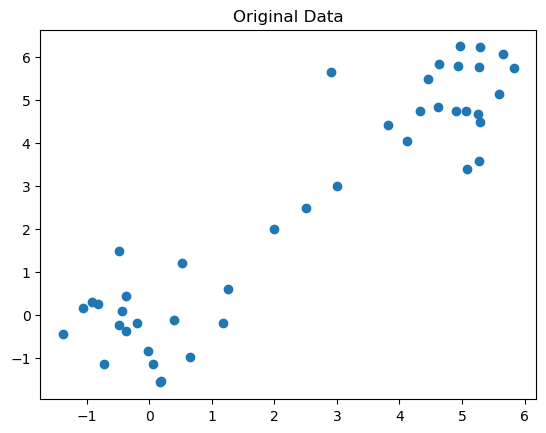

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 재현성
np.random.seed(42)

# 두 개 군집 생성
X, _ = make_blobs(
    n_samples=40,
    centers=[[0,0], [5,5]],
    cluster_std=0.8
)

# 가운데 연결점 추가 (중요!)
bridge = np.array([
    [2,2],
    [2.5,2.5],
    [3,3]
])

X = np.vstack([X, bridge])

# 데이터 시각화
plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()

# 점 3개가 두 군집을 연결하는 역할

In [24]:
# sklearn
from sklearn.cluster import AgglomerativeClustering

n_clusters = 2

# single linkage
model_single = AgglomerativeClustering(n_clusters= n_clusters, linkage= 'single')
model_complete = AgglomerativeClustering(n_clusters= n_clusters, linkage= 'complete')
model_average = AgglomerativeClustering(n_clusters= n_clusters, linkage= 'average')

label_single = model_single.fit_predict(X)
label_complete= model_complete.fit_predict(X)
label_average = model_average.fit_predict(X)

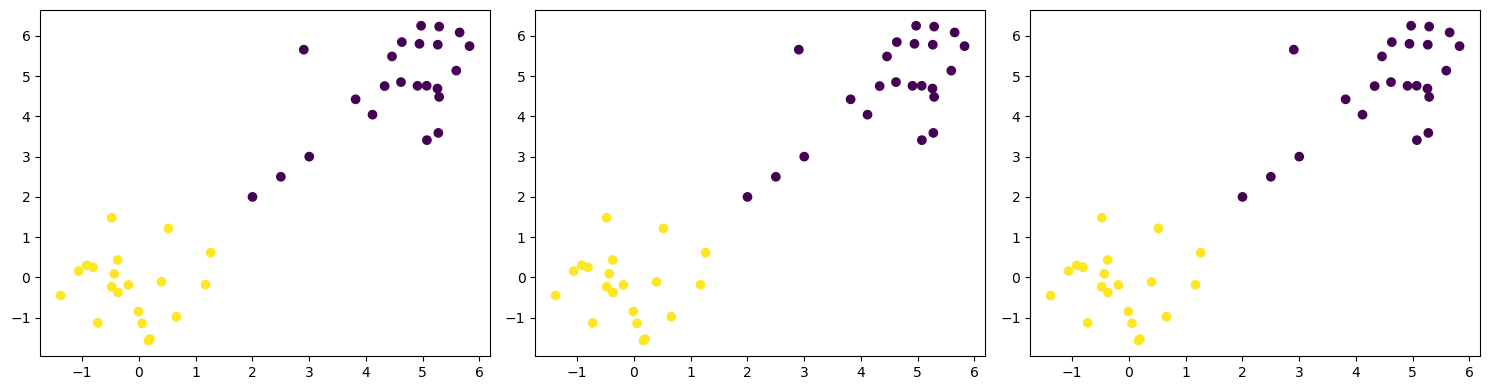

In [26]:
fig, ax = plt.subplots(1,3,figsize=(15,4))
ax[0].scatter(X[:, 0], X[:, 1], c = label_single)
ax[1].scatter(X[:, 0], X[:, 1], c = label_complete)
ax[2].scatter(X[:, 0], X[:, 1], c = label_average)

plt.tight_layout()
plt.show()

In [ ]:
# 군집
# kmeans, DBSCAN, hierarchy(single, complete, average)